**IMPORTS**

In [40]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import kagglehub
import random
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import Input

# Setting a seed to get the same accuracy results every time
seed_value = 33

os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)


In [41]:
# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fashionmnist' dataset.
Path to dataset files: /kaggle/input/fashionmnist


**LOADING DATA**

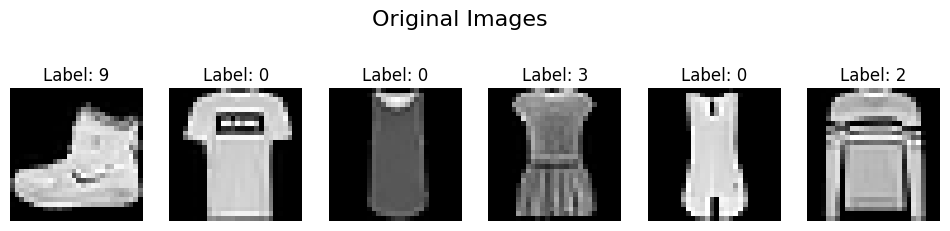

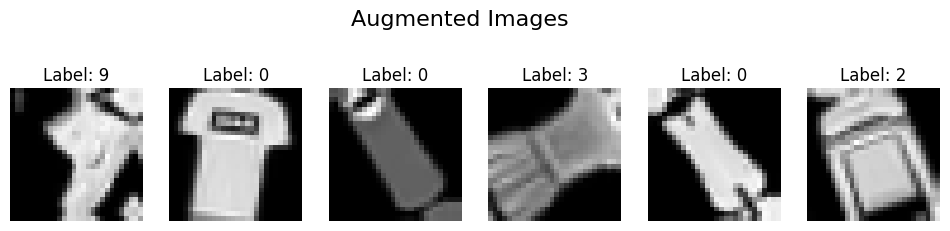

In [42]:
DATA_PATH = path

# Step 1: Load the Fashion MNIST Dataset from local
def load_fashion_mnist_data(path, kind='train'):
    """Load Fashion MNIST data from idx3-ubyte files."""
    if kind == 'train':
        labels_filename = 'train-labels-idx1-ubyte'
        images_filename = 'train-images-idx3-ubyte'
    else:
        labels_filename = 't10k-labels-idx1-ubyte'
        images_filename = 't10k-images-idx3-ubyte'

    labels_path = os.path.join(path, labels_filename)
    images_path = os.path.join(path, images_filename)

    with open(labels_path, 'rb') as lbpath:
        lbpath.seek(8)
        labels = np.fromfile(lbpath, dtype=np.uint8)

    with open(images_path, 'rb') as imgpath:
        imgpath.seek(16)
        images = np.fromfile(imgpath, dtype=np.uint8).reshape(len(labels), 28, 28)

    return images, labels
try:
    # Load training data
    train_images, train_labels = load_fashion_mnist_data(DATA_PATH, kind='train')
    # Load test data
    test_images, test_labels = load_fashion_mnist_data(DATA_PATH, kind='t10k')
except FileNotFoundError as e:
    print(f"Error loading file: {e.filename}")
    print(f"Please make sure the data files are located in the '{DATA_PATH}' directory.")
    exit()

# Define class names for the labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Step 2: Adding some data augmentation to increase the training dataset
augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=seed_value),
    tf.keras.layers.RandomRotation(0.2, seed=seed_value),
    tf.keras.layers.RandomZoom(0.2, seed=seed_value)
])

# Step 3: Preprocess the Data

train_images = train_images[..., None]
test_images = test_images[..., None]

augmented_images = augmenter(train_images)  #  Keras data augmentation expects a channel dimension (1 because it's grayscale)
augmented_images = augmented_images.numpy()  # remove channel dimension


# Concatenate with original data
train_images_expanded = np.concatenate([train_images, augmented_images], axis=0)
train_labels_expanded = np.concatenate([train_labels, train_labels], axis=0)


def show_samples(images, labels, title, num=6):
    plt.figure(figsize=(12, 3))
    plt.suptitle(title, fontsize=16)
    for i in range(num):
        plt.subplot(1, num, i+1)
        plt.imshow(images[i], cmap="gray")
        plt.title(f"Label: {labels[i]}")
        plt.axis("off")
    plt.show()

# Original images
show_samples(train_images, train_labels, "Original Images")

# Augmented images
show_samples(augmented_images, train_labels, "Augmented Images")



**IMAGE RESIZING TO FIT RESENT INPUT SHAPE**

In [43]:
def create_resnet_dataset(images, labels, batch_size=32):
    def preprocess_image(image, label):
        image = tf.image.resize(image, [224, 224])
        image = tf.repeat(image, 3, axis=-1)
        image = preprocess_input(image)
        return image, label

    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    dataset = dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = create_resnet_dataset(
    train_images,
    train_labels,
    batch_size=256
)

test_dataset = create_resnet_dataset(
    test_images,
    test_labels,
    batch_size=256)

# 新段落

**MODEL**

In [44]:
# Step 4: Build the Neural Network Model
augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="rgb_augmentation")

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

inputs = Input(shape=(224, 224, 3))
x = augmenter(inputs)

x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# Display a summary of the model's architecture
print("Model Summary:")
model.summary()

Model Summary:


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rgb_augmentation (Sequential)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,770,698 (94.49 MB)

 Trainable params: 24,717,578 (94.29 MB)

 Non-trainable params: 53,120 (207.50 KB)

**TRAINING**

In [45]:
# Step 6: Train the Model
print("\nStarting model training...")
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=test_dataset
)
print("Model training finished.")



Starting model training...
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 172s 574ms/step - accuracy: 0.7061 - loss: 0.8527 - val_accuracy: 0.8626 - val_loss: 0.3909
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 133s 564ms/step - accuracy: 0.9067 - loss: 0.2713 - val_accuracy: 0.9197 - val_loss: 0.2382
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 133s 564ms/step - accuracy: 0.9230 - loss: 0.2249 - val_accuracy: 0.9153 - val_loss: 0.2609
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 133s 564ms/step - accuracy: 0.9330 - loss: 0.1926 - val_accuracy: 0.9225 - val_loss: 0.2274
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 133s 565ms/step - accuracy: 0.9402 - loss: 0.1708 - val_accuracy: 0.9080 - val_loss: 0.2669
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 133s 564ms/step - accuracy: 0.9475 - loss: 0.1552 - val_accuracy: 0.9318 - val_loss: 0.2008
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 133s 564ms/step - accuracy: 0.9517 - loss: 0.1395 - val_accuracy: 0.9186 - val_loss: 0.2364
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 133s 564

**PLOTTING HELPER FUNCS**

In [46]:
# Helper functions to visualize the predictions
def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'
    plt.xlabel(f"{class_names[predicted_label]} {100*np.max(predictions_array):2.0f}% ({class_names[true_label]})",
               color=color)

def plot_value_array(i, predictions_array, true_label):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

**TESTING**


Evaluating model on test data...
40/40 - 5s - 120ms/step - accuracy: 0.9352 - loss: 0.2193

Test accuracy: 0.9352
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 161ms/step

Visualizing a prediction...


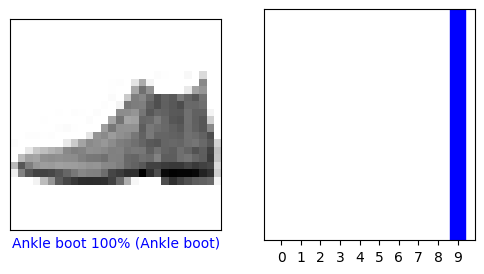


Plotting training history...


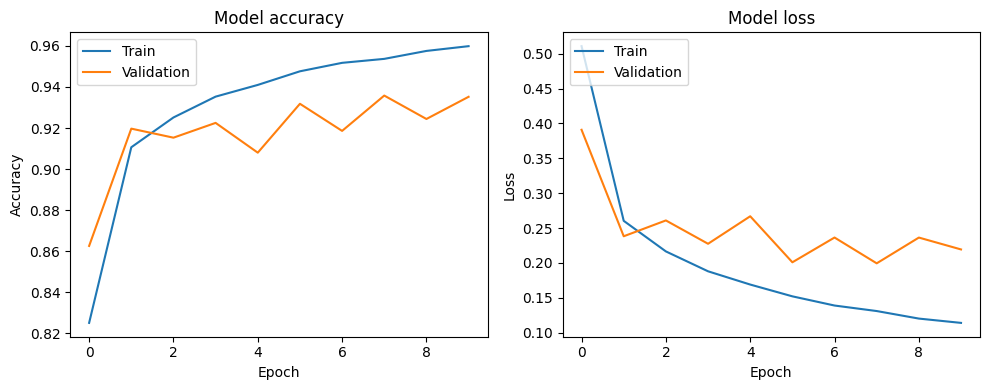

In [47]:
# Step 7: Evaluate the Model's Accuracy
print("\nEvaluating model on test data...")
test_loss, test_acc = model.evaluate(test_dataset, verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')

# Step 8: Make Predictions
predictions = model.predict(test_dataset)


# Let's visualize the prediction for the first image
print("\nVisualizing a prediction...")
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i], test_labels)
plt.show()

# Plot training & validation accuracy values
print("\nPlotting training history...")
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()